In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import missingno as msno
import re
from sklearn.preprocessing import LabelEncoder

In [48]:
df = pd.read_csv("../csv/used_cars.csv")
df2 = pd.read_csv("../csv/train.csv")

df = pd.concat([df, df2])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192542 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   brand         192542 non-null  object 
 1   model         192542 non-null  object 
 2   model_year    192542 non-null  int64  
 3   milage        192542 non-null  object 
 4   fuel_type     187289 non-null  object 
 5   engine        192542 non-null  object 
 6   transmission  192542 non-null  object 
 7   ext_col       192542 non-null  object 
 8   int_col       192542 non-null  object 
 9   accident      189977 non-null  object 
 10  clean_title   170527 non-null  object 
 11  price         192542 non-null  object 
 12  id            188533 non-null  float64
dtypes: float64(1), int64(1), object(11)
memory usage: 20.6+ MB


#### Visualizamos las columnas que tienen campos nulos, para poder tratarlos de la forma correcta.

In [49]:
df_copy = df.copy()

df_copy.isna().sum()

brand               0
model               0
model_year          0
milage              0
fuel_type        5253
engine              0
transmission        0
ext_col             0
int_col             0
accident         2565
clean_title     22015
price               0
id               4009
dtype: int64

<Axes: >

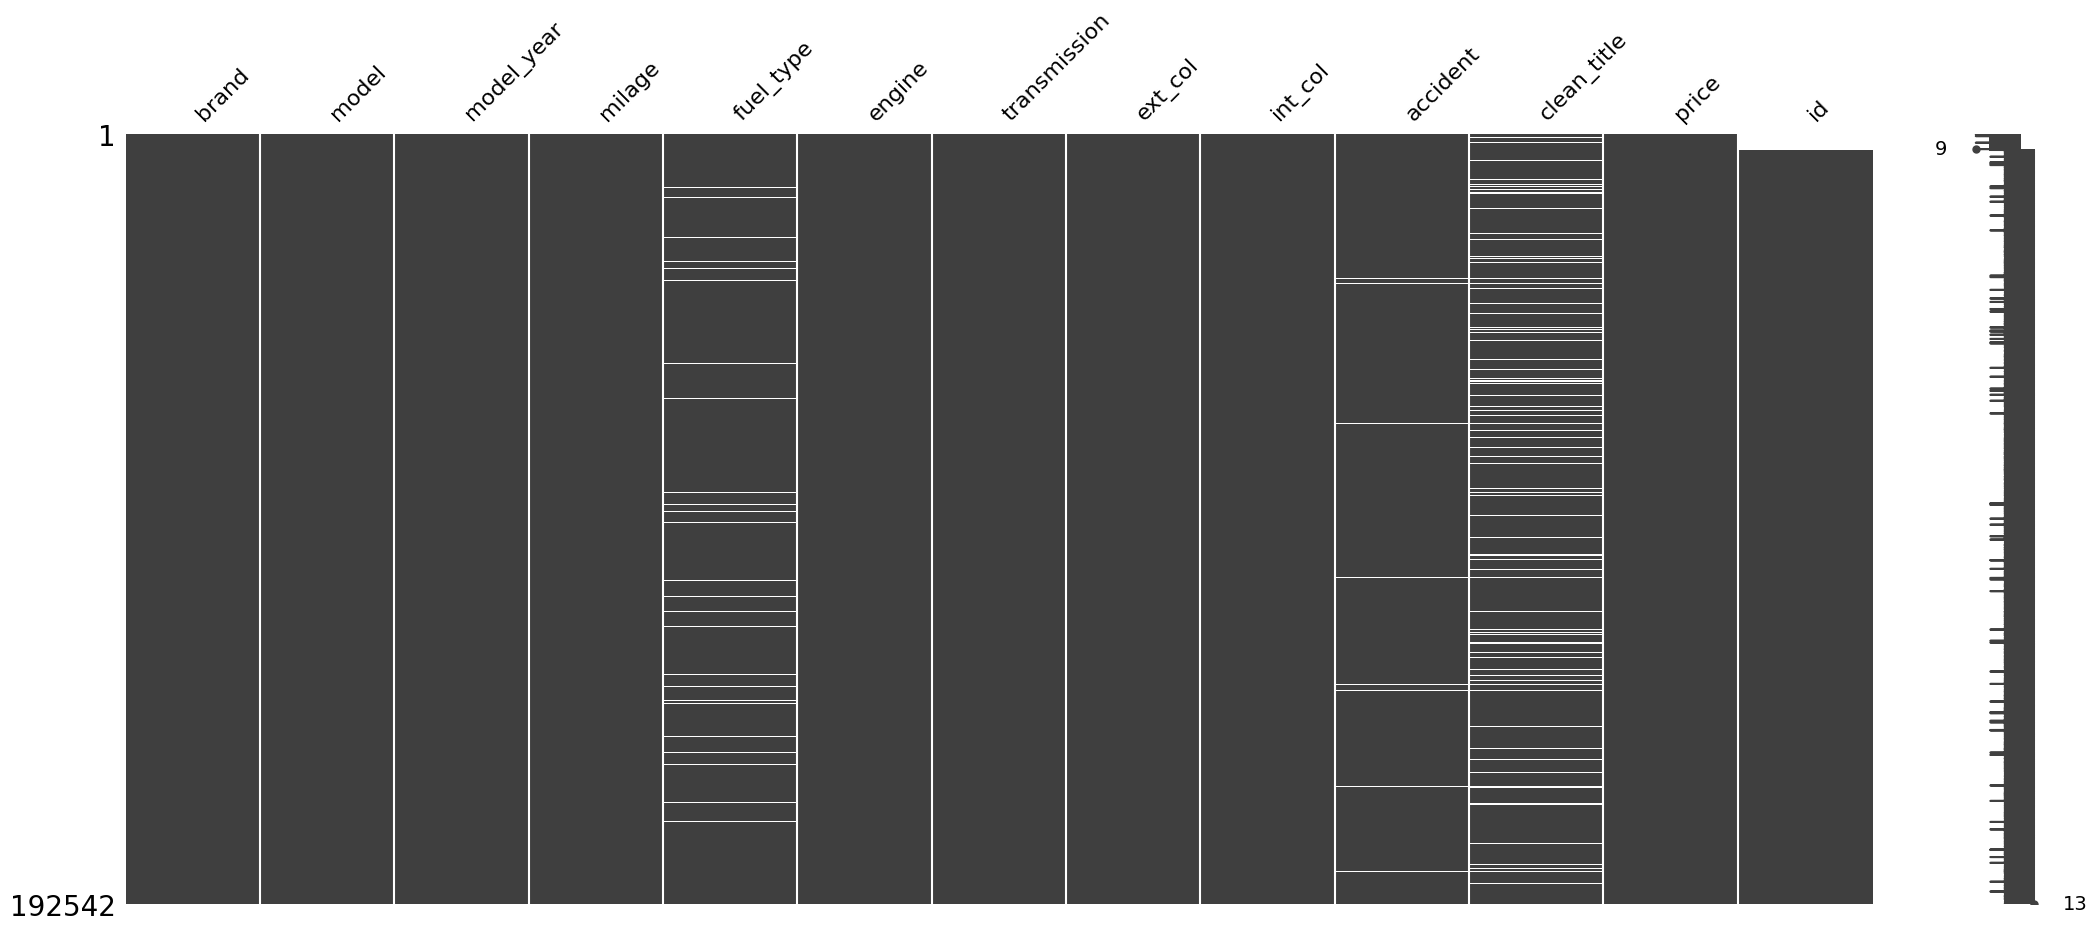

In [50]:
msno.matrix(df_copy)

#### Decidimos que no debemos eliminar los campos nulos de la colummna 'clean_title'. En lugar de eso cambiamos los valores vacíos por 'No', ya que el resto de campos esta rellenos con Yes, por lo que se entiende que los campos faltante no han sido recogidos con el valor correcto.

In [51]:
df_copy = df_copy[df_copy['model_year'] != 1974]

In [52]:
df_copy["clean_title"] = df_copy["clean_title"].fillna("No")

df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192529 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   brand         192529 non-null  object 
 1   model         192529 non-null  object 
 2   model_year    192529 non-null  int64  
 3   milage        192529 non-null  object 
 4   fuel_type     187276 non-null  object 
 5   engine        192529 non-null  object 
 6   transmission  192529 non-null  object 
 7   ext_col       192529 non-null  object 
 8   int_col       192529 non-null  object 
 9   accident      189966 non-null  object 
 10  clean_title   192529 non-null  object 
 11  price         192529 non-null  object 
 12  id            188521 non-null  float64
dtypes: float64(1), int64(1), object(11)
memory usage: 20.6+ MB


In [53]:
df_copy = df_copy.drop('id', axis=1)
df_copy.isna().sum()

brand              0
model              0
model_year         0
milage             0
fuel_type       5253
engine             0
transmission       0
ext_col            0
int_col            0
accident        2563
clean_title        0
price              0
dtype: int64

#### one-hot encoding para tipo de combustible

In [54]:
# 1️⃣ Normalizar texto (sin romper NaN)
df_copy['fuel_type'] = (
    df_copy['fuel_type']
        .replace('–', np.nan)   # guion largo → NaN
        .astype(str)
        .str.strip()
        .str.lower()
)

# 2️⃣ Mapping EXACTO según tus reglas
fuel_mapping = {
    'nan': 'electric',
    'not supported': 'electric',
    'e85 flex fuel': 'gasoline',
    'plug-in hybrid': 'hybrid',
    'gasoline': 'gasoline',
    'diesel': 'diesel',
    'hybrid': 'hybrid'
}

df_copy['fuel_type'] = df_copy['fuel_type'].replace(fuel_mapping)

# 3️⃣ Eliminar cualquier cosa que NO sea válida
valid_fuels = ['gasoline', 'diesel', 'hybrid', 'electric']
df_copy = df_copy[df_copy['fuel_type'].isin(valid_fuels)]

# 4️⃣ Mapeo numérico
fuel_map = {
    'hybrid': 0,
    'gasoline': 1,
    'diesel': 2,
    'electric': 3
}

df_copy['fuel_type_num'] = df_copy['fuel_type'].map(fuel_map).astype(int)

# 5️⃣ Accident
df_copy['accident'] = df_copy['accident'].fillna('None reported')


#### one-hot encoding para brand

In [55]:
brand_dummies = pd.get_dummies(
    df_copy['brand'],
    prefix='brand',
    drop_first=True  # evita multicolinealidad
)

df_copy = pd.concat([df_copy, brand_dummies], axis=1)

In [56]:
df_copy['fuel_type'].value_counts()

fuel_type
gasoline    174791
hybrid        7581
electric      6086
diesel        4071
Name: count, dtype: int64

#### Eliminamos el resto de campos nulos que quedan en nuestro dataset.

In [57]:
df_copy = df_copy.dropna()


In [58]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192529 entries, 0 to 188532
Data columns (total 69 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   brand                192529 non-null  object
 1   model                192529 non-null  object
 2   model_year           192529 non-null  int64 
 3   milage               192529 non-null  object
 4   fuel_type            192529 non-null  object
 5   engine               192529 non-null  object
 6   transmission         192529 non-null  object
 7   ext_col              192529 non-null  object
 8   int_col              192529 non-null  object
 9   accident             192529 non-null  object
 10  clean_title          192529 non-null  object
 11  price                192529 non-null  object
 12  fuel_type_num        192529 non-null  int64 
 13  brand_Alfa           192529 non-null  bool  
 14  brand_Aston          192529 non-null  bool  
 15  brand_Audi           192529 non-null  b

#### Normalización del campo 'transmission', muchos campos con el mismo valor pero escrito de distinta forma.

In [59]:
# Seleccionamos valores que queremos reemplazar y le asignamos el valor por el que deben ser reemplazados
mapping = {
    '10-Speed A/T': '10-Speed Automatic',
    'Atuomatic, 10-Spd': '10-Speed Automatic',

    '4-Speed A/T': '4-Speed Automatic',
    '5-Speed A/T': '5-Speed Automatic',
    '6-Speed A/T': '6-Speed Automatic',

    '6-Speed Mt': '6-Speed Manual',
    '6-Speed M/T': '6-Speed Manual',
    'Manual, 6-Spd': '6-Speed Manual',

    '7-Speed A/T': '7-Speed Automatic',
    '7-Speed M/T': '7-Speed Manual',

    '8-Speed A/T': '8-Speed Automatic',
    '8-SPEED A/T': '8-Speed Automatic',
    '8-Speed AT': '8-Speed Automatic',
    'Automatic, 8-Spd': '8-Speed Automatic',

    '9-Speed A/T': '9-Speed Automatic'
}

df_copy['transmission'] = df_copy['transmission'].replace(mapping)

In [60]:
df_copy['milage'] = df_copy['milage'].astype(str)
df_copy['price'] = df_copy['price'].astype(str)

#### Eliminado los caracteres 'mi.' y ',' para poder cambiar el texto a formato correcto.

In [61]:
df_copy['milage'] = df_copy['milage'].str.replace(' mi.', '', regex=True)
df_copy['milage'] = df_copy['milage'].str.replace(',', '', regex=True)
df_copy['milage'].head()

0    51000
1    34742
2    22372
3    88900
4     9835
Name: milage, dtype: object

In [62]:
df_copy['price'] = df_copy['price'].str.replace("$", "", regex=False)
df_copy['price'] = df_copy['price'].str.replace(',', '', regex=False)

#### Cambiamos la columna engine, sacando información de dicha columna y diviendola en varias columnas para tener los datos separados.

In [63]:
# =========================
# ENGINE LITERS
# =========================
engine_str = df_copy['engine'].astype(str).str.lower()

# Extraemos litros (3.5L, 3,5L, 2L)
liters = (
    engine_str
    .str.extract(r'(\d+[.,]?\d*)\s*l')[0]
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# CORRECCIÓN CLAVE:
# Si el valor es > 10, asumimos que falta el punto decimal (ej: 35 → 3.5)
liters = np.where(liters > 10, liters / 10, liters)

df_copy['engine_liters'] = np.nan_to_num(liters, nan=-1)

# =========================
# CYLINDERS
# =========================
df_copy['cylinders'] = pd.to_numeric(
    engine_str
    .str.extract(r'(\d+)\s*cylinder|v(\d+)', flags=re.I)
    .bfill(axis=1)
    .iloc[:, 0],
    errors='coerce'
).fillna(-1)

# =========================
# TURBO
# =========================
df_copy['turbo'] = engine_str.str.contains('turbo').astype(int)

# =========================
# Horse power
# =========================
engine_str = df_copy['engine'].astype(str).str.lower()

# Extraemos caballos de fuerza (HP) como entero
horsepower = (
    engine_str
    .str.extract(r'(\d+[.,]?\d*)\s*hp')[0]    # captura el número antes de 'hp'
    .str.replace(',', '.', regex=False)       # reemplaza coma por punto
    .fillna(-1)                               # rellenar los que no tengan HP
    .astype(float)                            # primero a float
    .astype(int)                              # luego a entero
)
df_copy['horsepower'] = np.nan_to_num(horsepower, nan=-1)


In [64]:
df_copy['brand'].value_counts()

brand
Ford             23466
Mercedes-Benz    19487
BMW              17403
Chevrolet        16627
Audi             11087
Porsche          10812
Land              9655
Toyota            9049
Lexus             8806
Jeep              6617
Cadillac          4781
RAM               4340
Nissan            4046
Tesla             3825
INFINITI          3335
GMC               3306
Dodge             3222
Mazda             2783
Kia               2573
Lincoln           2474
Subaru            2445
Acura             2346
Honda             2164
Hyundai           2117
Volkswagen        1824
Jaguar            1365
Bentley           1188
MINI              1097
Genesis            989
Maserati           973
Buick              970
Lamborghini        834
Volvo              761
Chrysler           755
Alfa               701
Rivian             607
Rolls-Royce        572
Mitsubishi         571
Pontiac            553
Hummer             536
Ferrari            371
McLaren            249
Aston              247
Satur

In [65]:
# Colores base a normalizar
base_colors = {
    "white": "White",
    "black": "Black",
    "gray": "Gray",
    "grey": "Gray",
    "silver": "Silver",
    "blue": "Blue",
    "red": "Red",
    "green": "Green",
    "brown": "Brown",
    "beige": "Beige",
    "tan": "Beige",
    "yellow": "Yellow",
    "gold": "Gold",
    "bianco": "Bianco",
    "orange": "Orange",
    "purple": "Purple"
}

# Construimos el diccionario de mapeo usando ambas columnas
color_mapping = {}

for key, base in base_colors.items():
    values = set(
        c
        for c in pd.concat([df_copy["ext_col"], df_copy["int_col"]])
        .dropna()
        .unique()
        if key in c.lower()
    )
    color_mapping.update({value: base for value in values})

# Aplicamos el reemplazo a ambas columnas
for col in ["ext_col", "int_col"]:
    df_copy[col] = df_copy[col].replace(color_mapping)


In [66]:
# Seleccionamos valores que queremos reemplazar y le asignamos el valor por el que deben ser reemplazados
mapping = {
    "Ebony.": "Ebony",
    "Ebony / Ebony Accents": "Ebony",
    "Ebony / Pimento": "Ebony",
    "Ebony/Light Oyster Stitch": "Ebony",
    "Graphite w/Gun Metal": "Graphite",
    "Parchment.": "Parchment"
}

df_copy['int_col'] = df_copy['int_col'].replace(mapping)

mapping = {
   "BLU ELOS": "Blue",
   "BLU": "Blue",
   "Verde": "Green" 
}

df_copy['ext_col'] = df_copy['ext_col'].replace(mapping)

In [67]:
mapping = {
    "At least 1 accident or damage reported": 1,
    "None reported": 0
}

df_copy['accident'] = df_copy['accident'].map(mapping).astype(int)

In [68]:
mapping = {
    "Yes": 1,
    "No": 0
}

df_copy['clean_title'] = df_copy['clean_title'].map(mapping).astype(int)

#### Una vez extraida la información y dividida eliminamos la columna 'engine'

In [69]:
df_copy.drop(columns='engine', inplace=True)

#### Cambiar tipo de datos de los campos

In [70]:
df_copy['milage'] = df_copy['milage'].astype(int)
df_copy['price'] = df_copy['price'].astype(int)
df_copy['engine_liters'] = df_copy['engine_liters'].astype(float)
df_copy['cylinders'] = df_copy['cylinders'].astype(int)
df_copy['turbo'].head()

0    0
1    0
2    0
3    0
4    1
Name: turbo, dtype: int64

#### one-hot encoding tipo de combustible

In [71]:
# Crear dummies
fuel_dummies = pd.get_dummies(
    df_copy['fuel_type'],  # la columna original
    prefix='fuel',         # prefijo para no confundir
    drop_first=False,      # mantienes todas las categorías
    dtype=int
)

# Unir al dataframe
df_copy = pd.concat([df_copy, fuel_dummies], axis=1)

In [72]:
df_copy.head()

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,...,brand_Volvo,brand_smart,engine_liters,cylinders,turbo,horsepower,fuel_diesel,fuel_electric,fuel_gasoline,fuel_hybrid
0,Ford,Utility Police Interceptor Base,2013,51000,gasoline,6-Speed Automatic,Black,Black,1,1,...,False,False,3.7,6,0,300,0,0,1,0
1,Hyundai,Palisade SEL,2021,34742,gasoline,8-Speed Automatic,Moonlight Cloud,Gray,1,1,...,False,False,3.8,6,0,-1,0,0,1,0
2,Lexus,RX 350 RX 350,2022,22372,gasoline,Automatic,Blue,Black,0,0,...,False,False,3.5,-1,0,-1,0,0,1,0
3,INFINITI,Q50 Hybrid Sport,2015,88900,hybrid,7-Speed Automatic,Black,Black,0,1,...,False,False,3.5,6,0,354,0,0,0,1
4,Audi,Q3 45 S line Premium Plus,2021,9835,gasoline,8-Speed Automatic,White,Black,0,0,...,False,False,2.0,-1,1,-1,0,0,1,0


#### Correlación de variables (Hay que tener en cuenta que muchas variables son columnas creadas a raíz de otras dandole simplemente un valor númerico y por ello no tienen una correlación especialmente alta)

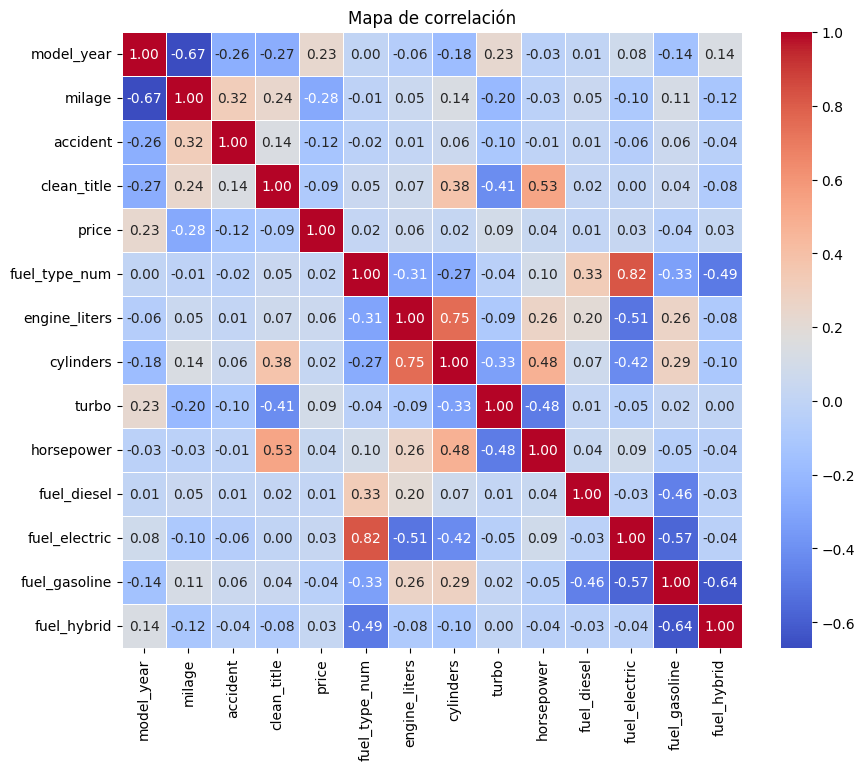

In [73]:
numeric_cols = df_copy.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Mapa de correlación")
plt.show()

#### Realización de gráficas para el EDA.

#### Que datos escoger para nuestro EDA

In [74]:
df_eda = df_copy.copy()
df_eda.head()

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,...,brand_Volvo,brand_smart,engine_liters,cylinders,turbo,horsepower,fuel_diesel,fuel_electric,fuel_gasoline,fuel_hybrid
0,Ford,Utility Police Interceptor Base,2013,51000,gasoline,6-Speed Automatic,Black,Black,1,1,...,False,False,3.7,6,0,300,0,0,1,0
1,Hyundai,Palisade SEL,2021,34742,gasoline,8-Speed Automatic,Moonlight Cloud,Gray,1,1,...,False,False,3.8,6,0,-1,0,0,1,0
2,Lexus,RX 350 RX 350,2022,22372,gasoline,Automatic,Blue,Black,0,0,...,False,False,3.5,-1,0,-1,0,0,1,0
3,INFINITI,Q50 Hybrid Sport,2015,88900,hybrid,7-Speed Automatic,Black,Black,0,1,...,False,False,3.5,6,0,354,0,0,0,1
4,Audi,Q3 45 S line Premium Plus,2021,9835,gasoline,8-Speed Automatic,White,Black,0,0,...,False,False,2.0,-1,1,-1,0,0,1,0


In [75]:
# Tipo de fuel : "Hybrid": 0, "Gasoline": 1, "Diesel": 2, "electric": 3
# accident: 0: no, 1: si
columnas = ['brand', 'model_year', 'milage', 'fuel_type_num', 'accident', 'price', 'clean_title']
df_eda_copy = df_eda[columnas]

#### Realizar scatterplot para ver los outliers que tiene nuestro dataset.

In [76]:
# Cálculo de límites
Q1 = df_copy['price'].quantile(0.25)
Q3 = df_copy['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

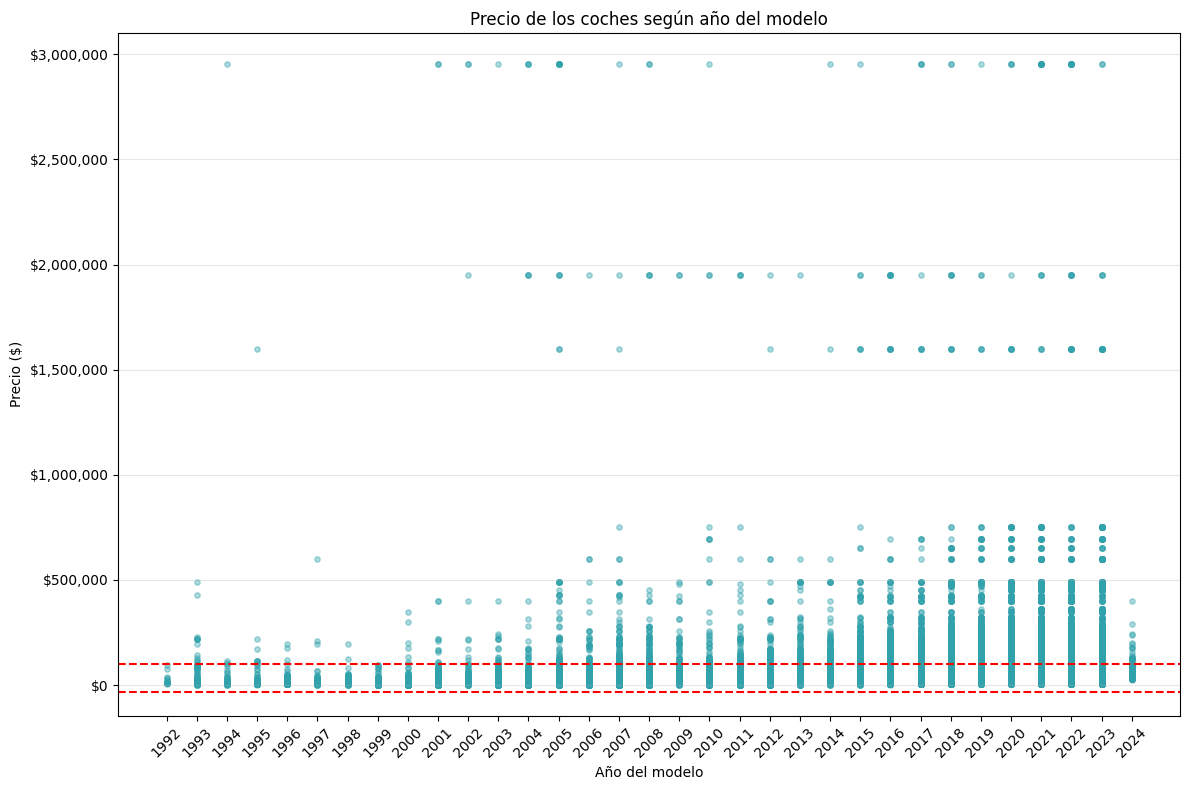

In [77]:
# Obtenemos todos los años presentes
years = sorted(df_copy['model_year'].unique())

plt.figure(figsize=(12, 8))

# Scatter de precio por año del modelo
plt.scatter(
    df_copy['model_year'],
    df_copy['price'],
    alpha=0.4,
    s=15,
    color='#31A2AC'
)

# Líneas de outliers
plt.axhline(upper_bound, color='red', linestyle='--', label='Límite superior')
plt.axhline(lower_bound, color='red', linestyle='--', label='Límite inferior')

# Etiquetas y título
plt.xlabel("Año del modelo")
plt.ylabel("Precio ($)")
plt.title("Precio de los coches según año del modelo")

# Mostrar todos los años en el eje X
plt.xticks(years, rotation=45)

# Formatear eje Y para que muestre precio real en dólares
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Grid y leyenda
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.show()


#### Podemos ver que coches se han vendido en los años con picos mas altos para ver si son coches de lujo o alta gama, o si simplemente hay un valor que hace que la media se dispare de forma desmesurada.

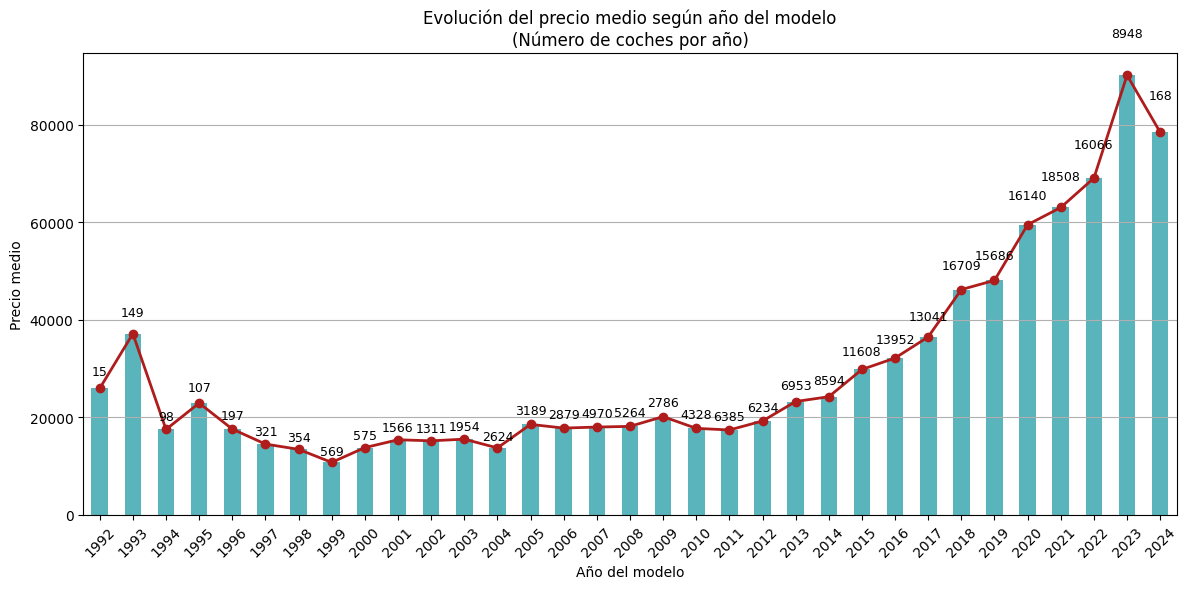

In [98]:
# Precio medio por año
price_by_year = (
    df_eda_copy
    .groupby('model_year')['price']
    .mean()
    .sort_index()
)

# Número de registros por año
count_by_year = (
    df_eda_copy
    .groupby('model_year')
    .size()
    .sort_index()
)

plt.figure(figsize=(12, 6))

# Gráfico de barras (precio medio)
ax = price_by_year.plot(
    kind='bar',
    color='#31A2AC',
    alpha=0.8
)

# Línea de tendencia
plt.plot(
    range(len(price_by_year)),
    price_by_year.values,
    marker='o',
    linewidth=2,
    color='#AF1C1C'
)

# Añadir etiquetas de conteo encima de cada barra
for i, year in enumerate(price_by_year.index):
    count = count_by_year.loc[year]
    
    offset = price_by_year.loc[year] * 0.08
    
    ax.text(
        i,
        price_by_year.loc[year] + offset,
        f'{count}',
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0
    )

plt.xlabel('Año del modelo')
plt.ylabel('Precio medio')
plt.title('Evolución del precio medio según año del modelo\n(Número de coches por año)')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Como vemos entre las dos graficas anteriores podemos observar que los outliers mas grandes se corresponden con los picos mas alto de las medias a lo largo de los años, habiendo en 2005 un pico tan alto debido a algun coche de alta gama cuyo valor es aproximado de unos 3 millones de dolares, aumentando significativamente el valor. 

#### Acompañado tambíen por otro outlier grande cuyo precio es de 1.5 millones aproximadamente.

#### En 2011 pasa algo similar nos encontramos con un desviación de la media aunque algo menos reseñable que otros años anteriores, esto se debe a un outlier cuyo valor es de 2 millones aproximadamente.

#### Con este gráfico de barras además vemos como a partir de 2010, vemos una tendencia alzista de la subida de los precios de los coches. (Buscar algun analisis significativo)

#### Representación de las marcas de los vehiculos.

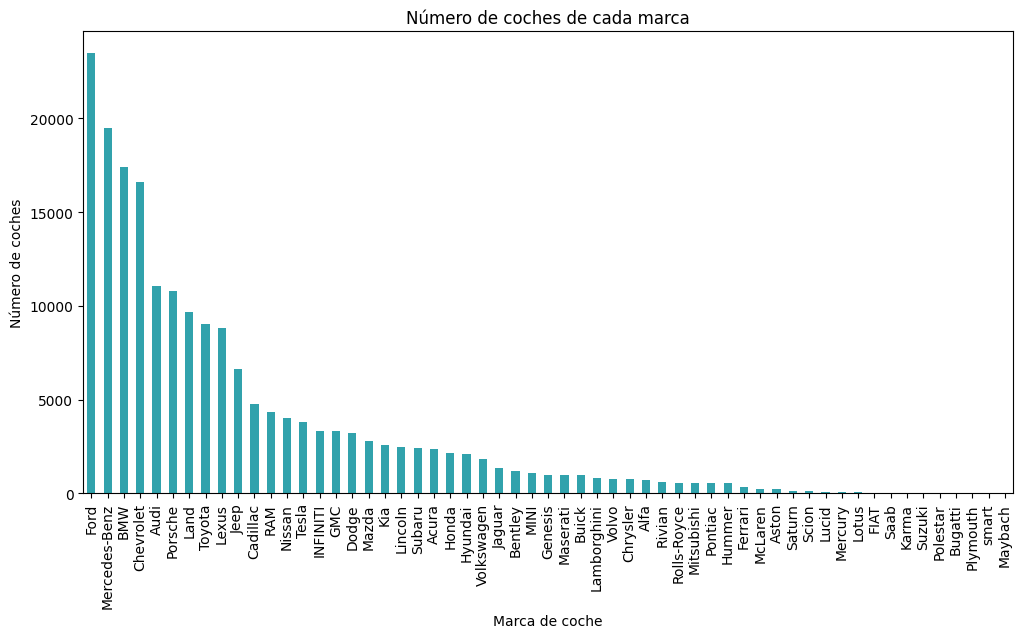

In [79]:
df_eda_copy['brand'].value_counts().plot(kind='bar', figsize=(12,6), color='#31A2AC')

plt.xlabel("Marca de coche")
plt.ylabel("Número de coches")
plt.title("Número de coches de cada marca")
plt.xticks(rotation=90)
plt.show()

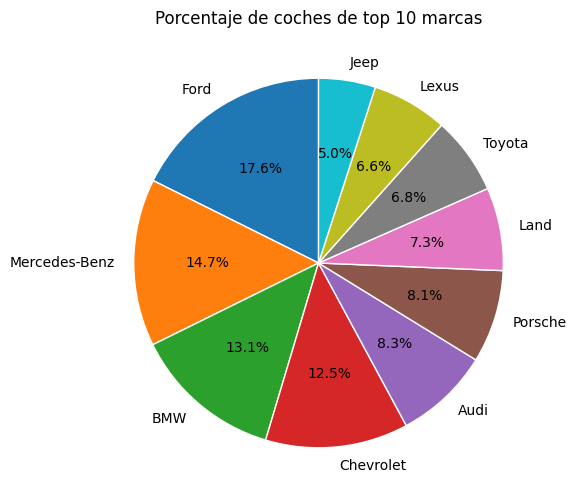

In [80]:
brand_count = df_eda_copy['brand'].value_counts().head(10)

plt.figure(figsize=(12,6))

plt.pie(
    brand_count.values,
    labels=brand_count.index,
    autopct='%1.1f%%',   # Muestra el porcentaje
    startangle=90,       
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Porcentaje de coches de top 10 marcas")
plt.xticks(rotation=90)
plt.show()

#### Una vez visto la representación que tiene cada marca, vamos a ver cual es el que tiene mayor precio medio de los 10 mas representados en los datos.

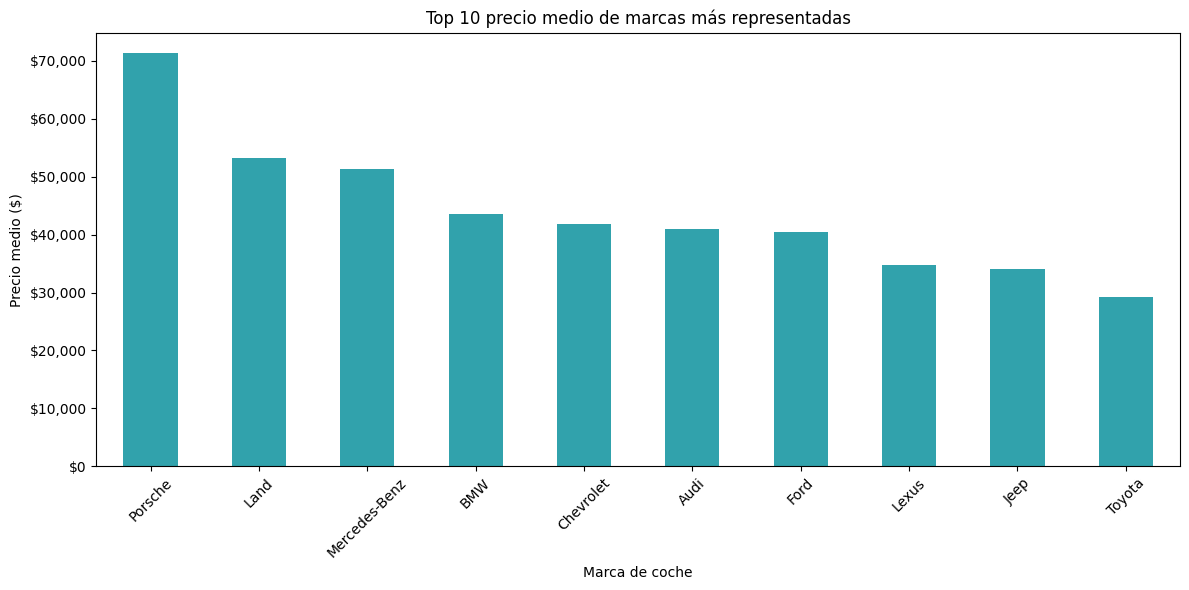

In [81]:
# 1️⃣ Contar cuántos coches hay por marca
brand_counts = df_eda_copy['brand'].value_counts()

# 2️⃣ Seleccionar top 10 marcas más representadas
top10_brands = brand_counts.head(10).index

# 3️⃣ Calcular precio medio de cada una de estas marcas
avg_price_top10 = (
    df_eda_copy[df_eda_copy['brand'].isin(top10_brands)]
    .groupby('brand')['price']
    .mean()
    .sort_values(ascending=False)  # para que las barras más altas queden primero
)

# 4️⃣ Graficar
plt.figure(figsize=(12,6))
avg_price_top10.plot(kind='bar', color='#31A2AC')

plt.xlabel("Marca de coche")
plt.ylabel("Precio medio ($)")
plt.title("Top 10 precio medio de marcas más representadas")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))  # formato $ con coma
plt.tight_layout()
plt.show()

#### Como podemos ver el precio medio mayor la tiene con amplia diferencia porsche que es una marca de lujo. Con esto tambien podemos ver si algun valor de porsche se corresponde con los outliers marcados o si hay alguna otra marca de lujo que sea la que esta viciando algunos datos.

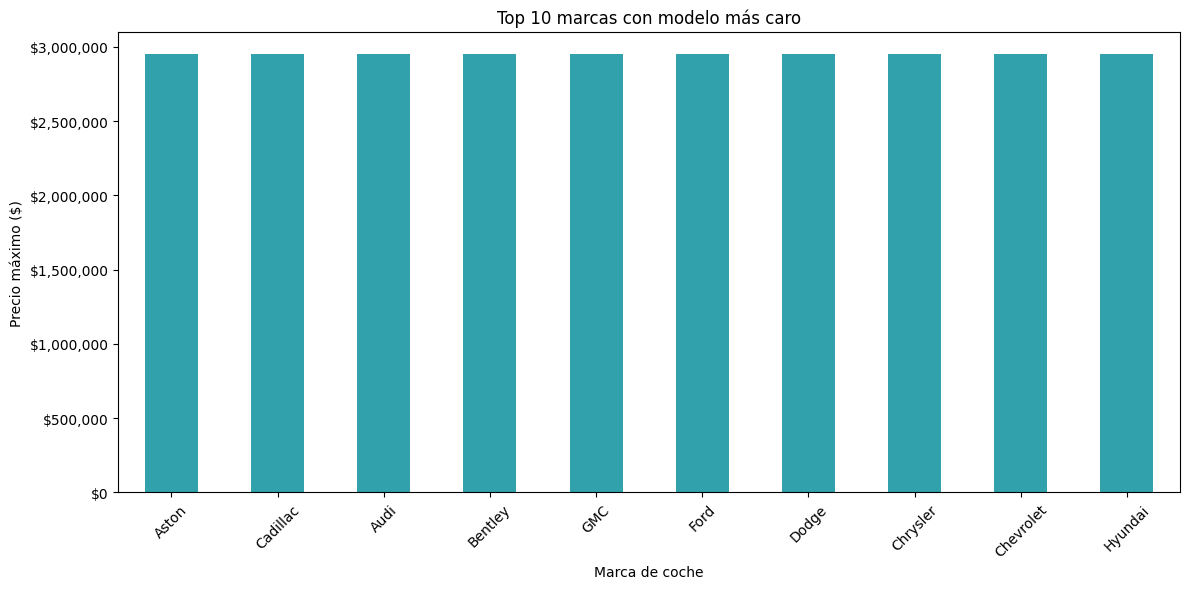

In [82]:
# 1️⃣ Calcular precio máximo por marca
max_price_by_brand = df_eda_copy.groupby('brand')['price'].max()

# 2️⃣ Seleccionar las 10 marcas con precio máximo más alto
top10_expensive_brands = max_price_by_brand.sort_values(ascending=False).head(10)

# 3️⃣ Graficar
plt.figure(figsize=(12,6))
top10_expensive_brands.plot(kind='bar', color='#31A2AC')

plt.xlabel("Marca de coche")
plt.ylabel("Precio máximo ($)")
plt.title("Top 10 marcas con modelo más caro")
plt.xticks(rotation=45)

# Formatear eje Y en dólares
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()


#### Aqui podemos ver cuales serian los 10 outliers mas grandes que se representan dentro del dataset. Como podemos ver Las principales marcas de lujo que mas podria disparar es masetati, bugatti, porsche y a la par lamborghini y roll-royce.

#### Grafica de precio medio por tipo de combustible

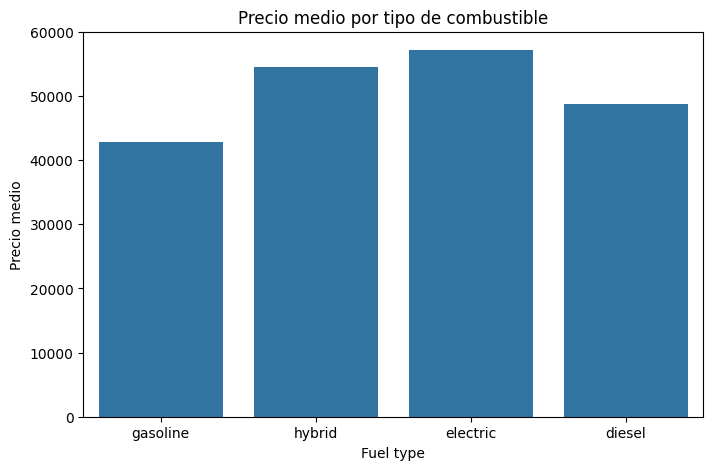

In [83]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_copy,
    x='fuel_type',
    y='price',
    estimator='mean',
    errorbar=None
)
plt.title('Precio medio por tipo de combustible')
plt.xlabel('Fuel type')
plt.ylabel('Precio medio')
plt.show()


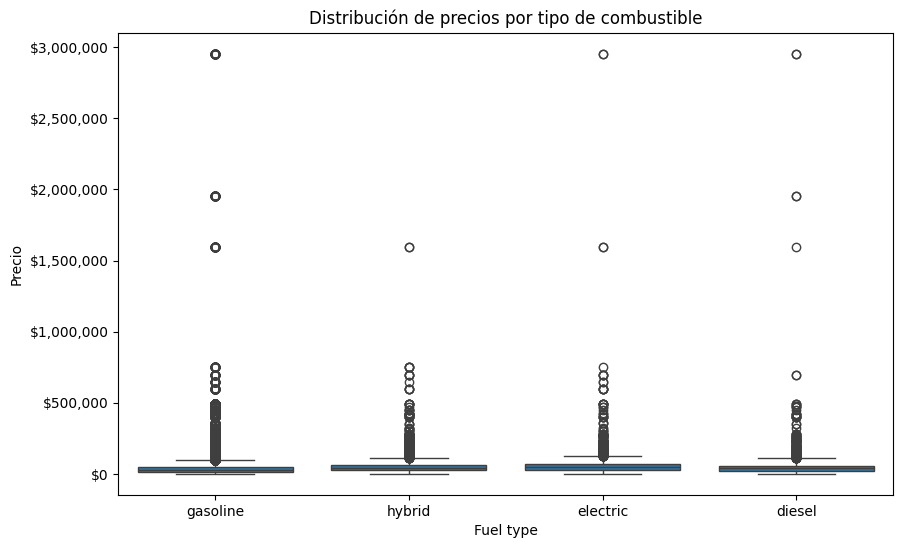

In [84]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_copy,
    x='fuel_type',
    y='price'
)
plt.title('Distribución de precios por tipo de combustible')
plt.xlabel('Fuel type')
plt.ylabel('Precio')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.show()

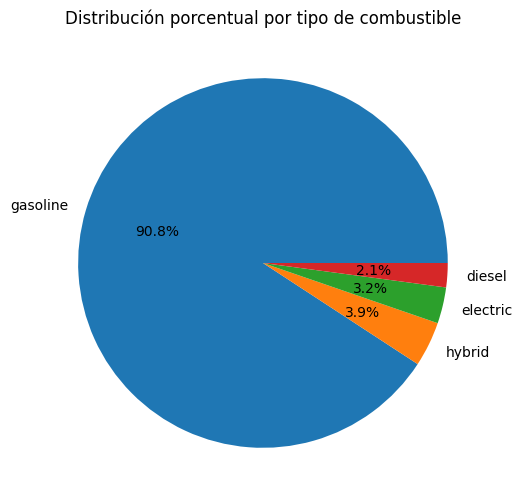

In [85]:
fuel_counts = df_copy['fuel_type'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))
fuel_counts.plot(kind='pie', autopct='%.1f%%')
plt.title('Distribución porcentual por tipo de combustible')
plt.ylabel('')
plt.show()


#### Marca y tipo de combustible

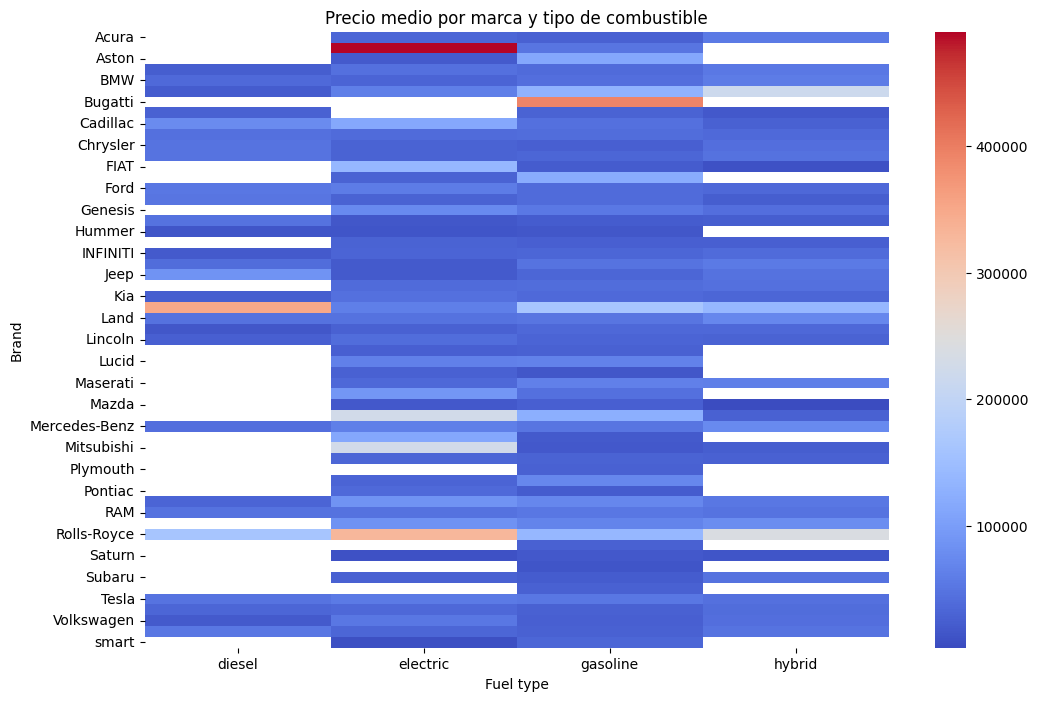

In [86]:
pivot_price = (
    df_copy
    .groupby(['brand', 'fuel_type'])['price']
    .mean()
    .unstack()
)

plt.figure(figsize=(12,8))
sns.heatmap(
    pivot_price,
    cmap='coolwarm',
    annot=False
)
plt.title('Precio medio por marca y tipo de combustible')
plt.xlabel('Fuel type')
plt.ylabel('Brand')
plt.show()


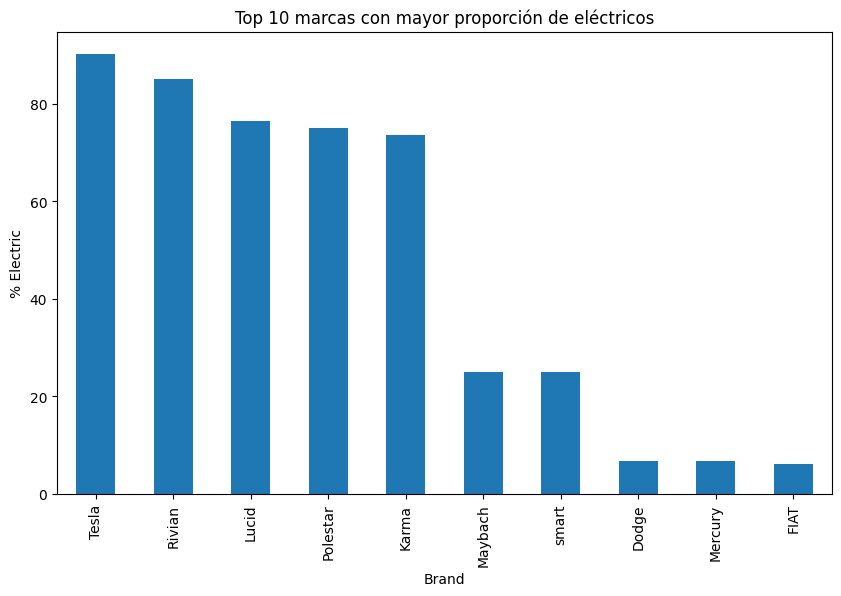

In [87]:
# Proporción de coches eléctricos por marca (%)
electric_share = (
    df_copy
        .assign(is_electric=(df_copy['fuel_type'] == 'electric').astype(int))
        .groupby('brand')['is_electric']
        .mean()
        .sort_values(ascending=False) * 100
)

top_electric_brands = electric_share.head(10)

plt.figure(figsize=(10,6))
top_electric_brands.plot(kind='bar')
plt.title('Top 10 marcas con mayor proporción de eléctricos')
plt.ylabel('% Electric')
plt.xlabel('Brand')
plt.show()


In [88]:
df_eda.head()

,brand,model,model_year,milage,fuel_type,transmission,ext_col,int_col,accident,clean_title,...,brand_Volvo,brand_smart,engine_liters,cylinders,turbo,horsepower,fuel_diesel,fuel_electric,fuel_gasoline,fuel_hybrid
0,Ford,Utility Police Interceptor Base,2013,51000,gasoline,6-Speed Automatic,Black,Black,1,1,...,False,False,3.7,6,0,300,0,0,1,0
1,Hyundai,Palisade SEL,2021,34742,gasoline,8-Speed Automatic,Moonlight Cloud,Gray,1,1,...,False,False,3.8,6,0,-1,0,0,1,0
2,Lexus,RX 350 RX 350,2022,22372,gasoline,Automatic,Blue,Black,0,0,...,False,False,3.5,-1,0,-1,0,0,1,0
3,INFINITI,Q50 Hybrid Sport,2015,88900,hybrid,7-Speed Automatic,Black,Black,0,1,...,False,False,3.5,6,0,354,0,0,0,1
4,Audi,Q3 45 S line Premium Plus,2021,9835,gasoline,8-Speed Automatic,White,Black,0,0,...,False,False,2.0,-1,1,-1,0,0,1,0


#### Regrsiones para el machine learning

In [89]:
df_eda_copy =df_eda_copy[df_eda['price'] <= 600000]

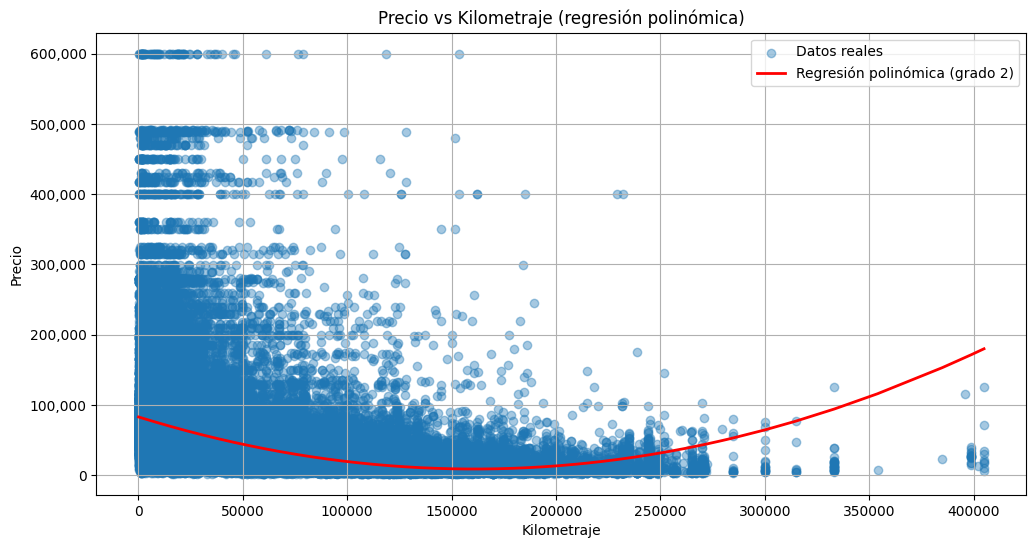

In [90]:
# Variables
x = df_eda_copy['milage'].values
y = df_eda_copy['price'].values

# Polinomio de grado 2 (curva)
coef = np.polyfit(x, y, 2)
poly = np.poly1d(coef)

# Valores ordenados para dibujar la curva
x_sorted = np.sort(x)
y_poly = poly(x_sorted)

# Gráfico
plt.figure(figsize=(12,6))
plt.scatter(x, y, alpha=0.4, label='Datos reales')
plt.plot(x_sorted, y_poly, color='red', linewidth=2, label='Regresión polinómica (grado 2)')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.xlabel('Kilometraje')
plt.ylabel('Precio')
plt.title('Precio vs Kilometraje (regresión polinómica)')
plt.legend()
plt.grid(True)
plt.show()


#### Explicacion de porque se queda la grafica superior.

In [91]:
df_copy.to_csv("..\\csv\\clean_cars.csv", index=False)